In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Ejercicio 1

Considere el sistema y[n] = 0,3y[n − 1] − 0,4y[n − 2] + 0,2y[n − 3] + x[n] y genere una secuencia de salida a una entrada de tipo aleatoria con distribución uniforme y valor medio cero. Utilizando esta señal de salida implemente el método de predicción lineal y verifique el comportamiento de los criterios para estimación del orden

In [2]:
N = 3000
rng = np.random.default_rng(42)
x = rng.uniform(-5, 5, N)
x = x - np.mean(x) 

# y[n] = 0.3y[n-1] - 0.4y[n-2] + 0.2y[n-3] + x[n] 
y = np.zeros(N)
for n in range(N):
    term1 = 0.3 * y[n-1] if n >= 1 else 0
    term2 = -0.4 * y[n-2] if n >= 2 else 0
    term3 = 0.2 * y[n-3] if n >= 3 else 0
    y[n] = term1 + term2 + term3 + x[n]

In [3]:

def autocorrelacion(x):
    N = len(x)
    r = np.zeros(N+N-1)

    for n in range(N+N-1):
        lag = n - (N - 1)
        for k in range(N):
            indice_desplazado = k + lag
            if 0 <= indice_desplazado < N:
                r[n] += x[k] * x[indice_desplazado]
    return r

r = autocorrelacion(y)

orden = 30 # aca elegimos el p max
limite = orden + 1
centro = len(y) - 1

# tomamos lo que necesitamos, del medio hasta el la cantidad del orden + 1
r_cortada = r[centro : centro + limite]

print(f"r[0], r[1], r[2], ...,r[{orden}]:")
print(r_cortada)

r[0], r[1], r[2], ...,r[30]:
[ 3.08937146e+04  5.13384587e+03 -9.51421222e+03  1.77501256e+03
  5.56135959e+03 -1.67439172e+03 -2.98942762e+03  1.12976421e+03
  1.05561365e+03 -2.95665304e+02 -8.20559440e+02 -6.18727337e+02
 -1.74765448e+02 -2.34136293e+02 -4.46272023e+02 -3.80779949e+02
  4.65263021e+01  4.33573455e+01 -2.27560755e+02 -3.71285566e+02
 -1.00415494e+03 -7.15585552e+02  1.20490713e+03  7.15883950e+02
 -1.29213208e+03 -2.82769773e+01  9.99849353e+02 -3.92150582e+02
 -2.65396050e+02  2.75127637e+01 -8.03023412e+02]


El orden óptimo detectado es: p = 3
Parámetros identificados para p=3: [-0.2975173   0.39303421 -0.21439417]


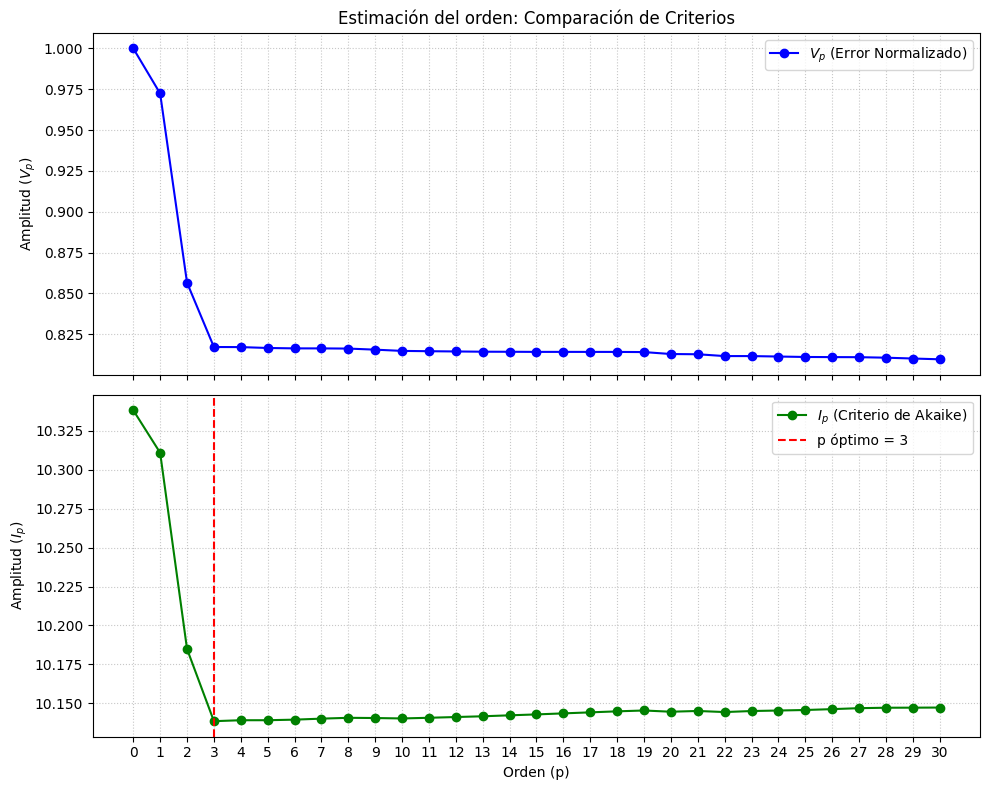

In [4]:

def levinson_durbin(r, p):
    a = np.zeros((p + 1, p + 1))
    k = np.zeros(p + 1)
    E = np.zeros(p + 1)

    E[0] = r[0]

    for i in range(1, p + 1):

      # 1 <= i <= p
      suma = 0
      for j in range(1, i):
          suma += a[j, i-1] * r[i-j]

      k[i] = - (r[i] + suma) / E[i-1]

      # 2
      a[i, i] = k[i]

      # 3 para 1 <= j <= i-1
      for j in range(1, i):
          a[j, i] = a[j, i-1] + k[i] * a[i-j, i-1]

      # 4
      E[i] = E[i-1] * (1 - k[i]**2)

    coeficientes_finales = a[1:, p]

    return coeficientes_finales, E, a

# coefs = coeficientes finales, 
# E = error de prediccion 
# matriz_A = matriz de coeficientes intermedios,
coefs, E, matriz_A = levinson_durbin(r_cortada, orden)

p_array = np.arange(orden + 1)
# Error normalizado Vp 
V_p = E / r_cortada[0]
# Criterio de Akaike Ip
I_p = np.log(E) + (2 * p_array) / N

orden_optimo = np.argmin(I_p[1:]) + 1


print(f"El orden óptimo detectado es: p = {orden_optimo}")
print(f"Parámetros identificados para p={orden_optimo}: {matriz_A[1:orden_optimo+1, orden_optimo]}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(p_array, V_p, label='$V_p$ (Error Normalizado)', color='blue', marker='o')
ax1.set_title("Estimación del orden: Comparación de Criterios")
ax1.set_ylabel("Amplitud ($V_p$)")
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

ax2.plot(p_array, I_p, label='$I_p$ (Criterio de Akaike)', color='green', marker='o')
ax2.axvline(x=orden_optimo, color='red', linestyle='--', label=f'p óptimo = {orden_optimo}')
ax2.set_xlabel("Orden (p)")
ax2.set_ylabel("Amplitud ($I_p$)")
ax2.set_xticks(np.arange(0, orden + 1, step=1))
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

## Ejercicio 2

La señal de electroencefalograma se puede modelar mediante un sistema AR de orden cuatro a ocho. Identifique el sistema que generó la señal almacenada en el archivo eeg.txt y compare la respuesta en frecuencia de este sistema con el espectro de la señal.

El orden para aproximación: p = 8
Parámetros identificados para p=8: [-1.65910375e+00  7.14685251e-01 -2.41206418e-01  1.53621196e-01
  3.28661856e-01 -3.55908026e-01 -9.59029408e-04  6.48724405e-02]


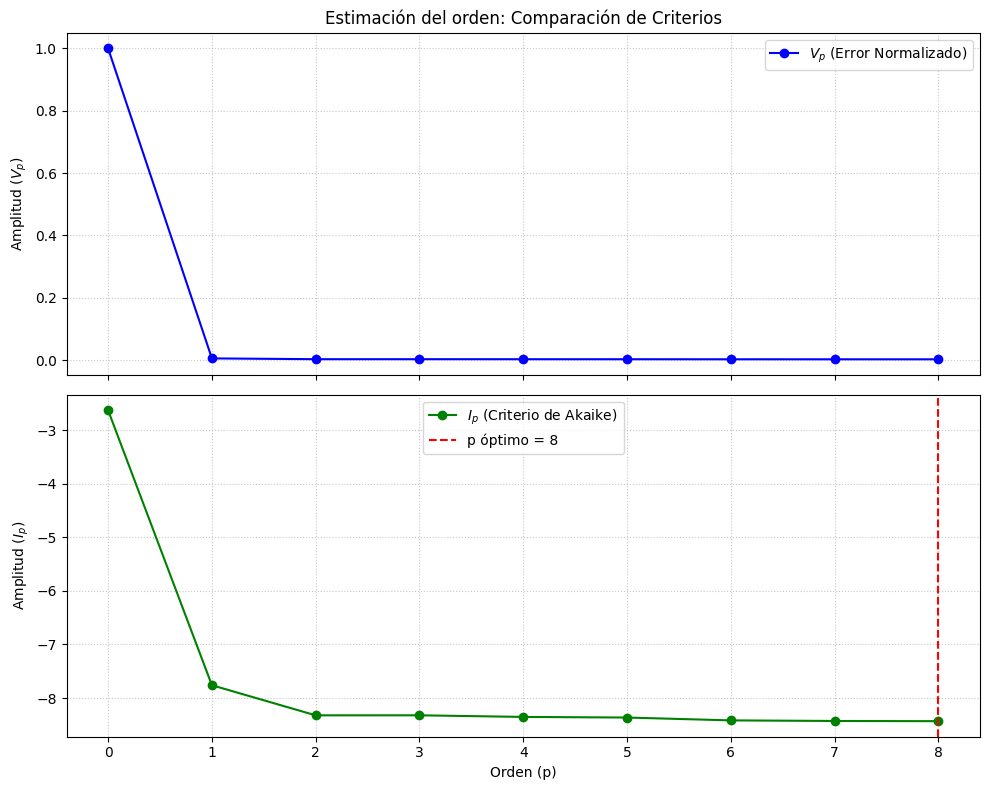

In [5]:
salida = np.loadtxt('eeg.txt')
salida = (salida - np.mean(salida))/np.max(np.abs(salida))
N_muestras = len(salida)

r = autocorrelacion(salida)

orden = 8 # aca elegimos el p max
limite = orden + 1
centro = len(salida) - 1

# tomamos lo que necesitamos, del medio hasta el la cantidad del orden + 1
r_cortada = r[centro : centro + limite] / N_muestras

# coefs = coeficientes finales, 
# E = error de prediccion 
# matriz_A = matriz de coeficientes intermedios
coefs, E, matriz_A = levinson_durbin(r_cortada, orden)

p_array = np.arange(orden + 1)
# Error normalizado Vp - no sirve de nada igual
V_p = E / r_cortada[0]
# Criterio de Akaike Ip
I_p = np.log(E) + (2 * p_array) / N_muestras

orden_optimo = np.argmin(I_p[1:]) + 1

coef_optimos = matriz_A[1:orden_optimo+1, orden_optimo]

print(f"El orden para aproximación: p = {orden_optimo}")
print(f"Parámetros identificados para p={orden_optimo}: {coef_optimos}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(p_array, V_p, label='$V_p$ (Error Normalizado)', color='blue', marker='o')
ax1.set_title("Estimación del orden: Comparación de Criterios")
ax1.set_ylabel("Amplitud ($V_p$)")
ax1.grid(True, linestyle=':', alpha=0.7)
ax1.legend()

ax2.plot(p_array, I_p, label='$I_p$ (Criterio de Akaike)', color='green', marker='o')
ax2.axvline(x=orden_optimo, color='red', linestyle='--', label=f'p óptimo = {orden_optimo}')
ax2.set_xlabel("Orden (p)")
ax2.set_ylabel("Amplitud ($I_p$)")
ax2.set_xticks(np.arange(0, orden + 1, step=1))
ax2.grid(True, linestyle=':', alpha=0.7)
ax2.legend()

plt.tight_layout()
plt.show()

In [6]:

rng = np.random.default_rng(42)

error_optimo = E[orden_optimo] 
desviacion_ruido = np.sqrt(error_optimo)
print(f"Desviación del ruido: {desviacion_ruido}")
x = rng.normal(0, desviacion_ruido, N_muestras)
print(f"x: {x[:10]}")  # Imprime las primeras 10 muestras del ruido generado

#  Parámetros identificados para p=8: [-1.65910375e+00  7.14685251e-01 -2.41206418e-01  1.53621196e-01 3.28661856e-01 -3.55908026e-01 -9.59029401e-04  6.48724405e-02]
# y[n] = 1.65910375e+00y[n-1] - 7.14685251e-01y[n-2] + 2.41206418e-01y[n-3] - 1.53621196e-01y[n-4] - 3.28661856e-01y[n-5] + 3.55908026e-01y[n-6] + 9.59029401e-04y[n-7] - 6.48724405e-02y[n-8] + x[n] 
y = np.zeros(N_muestras)
for n in range(N_muestras):
    term1 = -coef_optimos[0] * y[n-1] if n >= 1 else 0
    term2 = -coef_optimos[1] * y[n-2] if n >= 2 else 0
    term3 = -coef_optimos[2] * y[n-3] if n >= 3 else 0
    term4 = -coef_optimos[3] * y[n-4] if n >= 4 else 0
    term5 = -coef_optimos[4] * y[n-5] if n >= 5 else 0
    term6 = -coef_optimos[5] * y[n-6] if n >= 6 else 0
    term7 = -coef_optimos[6] * y[n-7] if n >= 7 else 0
    term8 = -coef_optimos[7] * y[n-8] if n >= 8 else 0
    y[n] = term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + x[n]

Desviación del ruido: 0.014734012863585463
x: [ 0.00448971 -0.01532314  0.01105716  0.01385829 -0.02874658 -0.01918633
  0.0018836  -0.00465952 -0.00024755 -0.01256876]


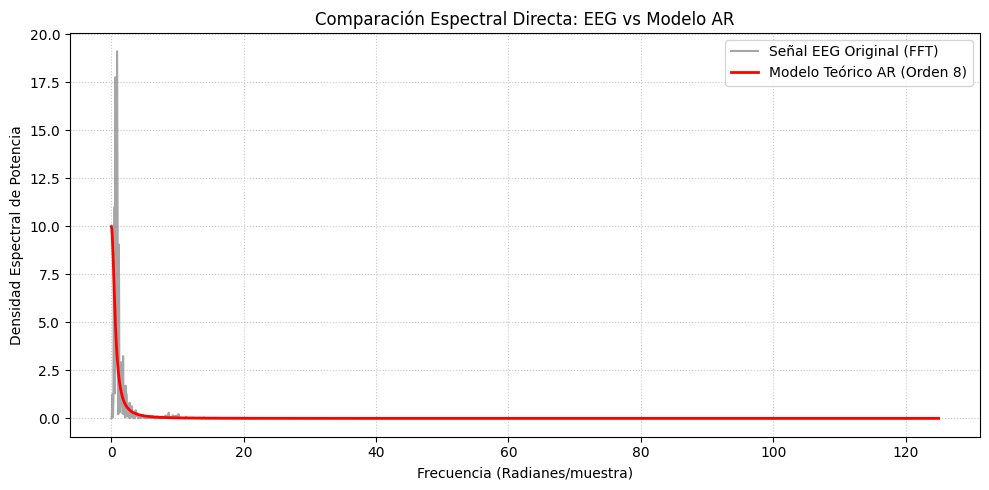

In [7]:
fs = 250.0 # Frecuencia de muestreo del archivo eeg.txt
N_FFT = 4096

# d = 1/fs le indica a la FFT el "Periodo de muestreo" (cuánto tiempo físico hay entre cada muestra)
frecuencias = np.fft.rfftfreq(N_FFT, d=1.0/fs) 
#print(f"Frecuencias calculadas por rfftfreq: {frecuencias[2045:2055]}")  # Imprime las primeras 10 frecuencias

# calculamos 4096 puntos de resolución para que el gráfico quede suave.
# como le informamos el tiempo real (d), rfftfreq nos devuelve directamente FRECUENCIAS FÍSICAS.
# el eje X ahora se mide en HERTZ (Hz).
# el rango del vector va desde 0 Hz hasta 125 Hz (que es fs/2, la frecuencia de Nyquist).

# Espectro empírico de la señal EEG
fft_orig = np.fft.rfft(salida, n=N_FFT)
# Calcula la DFT de tu señal salida
psd_orig = (np.abs(fft_orig)**2) / N_muestras 
# La transformada devuelve números complejos. 
# Para saber cuánta "energía" hay en cada frecuencia sacamos el módulo y lo elevamos al cuadrado
# Al dividir por N, convertimos esa Energía total en Densidad Espectral de Potencia (PSD) promedio.
# P_xx(omega) = 1/N * |X(e^{j\omega})|^2

# Espectro teórico del Modelo AR
denominador_AR = np.concatenate(([1], coef_optimos))
fft_denominador = np.fft.rfft(denominador_AR, n=N_FFT)
#esto seria A(z) del modelo AR
psd_AR = error_optimo / (np.abs(fft_denominador)**2) # S_xx = E_p / |A(f)|^2
# H(z) = G / A(z)

plt.figure(figsize=(10, 5))
plt.plot(frecuencias, psd_orig, label='Señal EEG Original (FFT)', color='gray', alpha=0.7)
plt.plot(frecuencias, psd_AR, label=f'Modelo Teórico AR (Orden {orden_optimo})', color='red', linewidth=2)

plt.title("Comparación Espectral Directa: EEG vs Modelo AR")
plt.xlabel("Frecuencia (Radianes/muestra)")
plt.ylabel("Densidad Espectral de Potencia")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

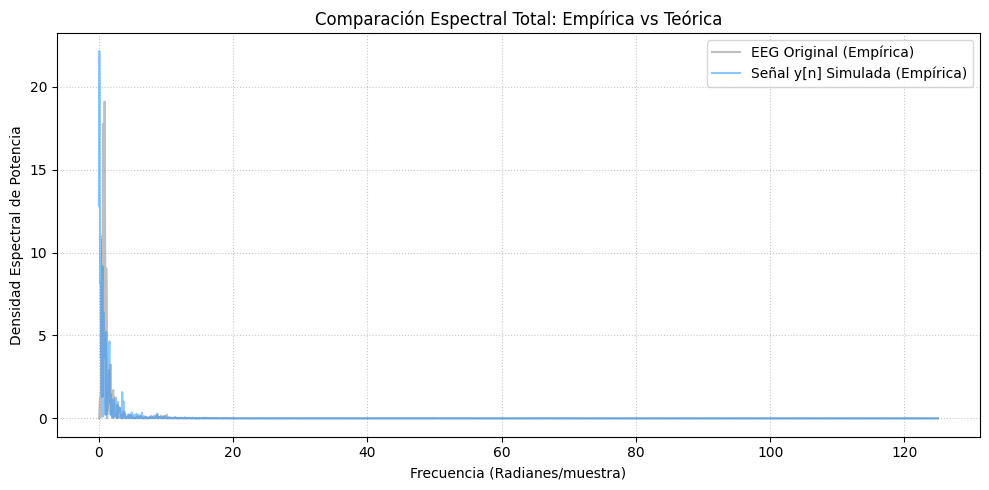

In [8]:
# señal EEG ORIGINAL
fft_orig = np.fft.rfft(salida, n=N_FFT)
psd_orig = (np.abs(fft_orig)**2) / N_muestras 

# SEÑAL SIMULADA y[n] (Periodograma)
fft_simulada = np.fft.rfft(y, n=N_FFT)
psd_simulada = (np.abs(fft_simulada)**2) / N_muestras


# GRÁFICOS
plt.figure(figsize=(10, 5))

# Señal Original (Ruidosa)
plt.plot(frecuencias, psd_orig, label='EEG Original (Empírica)', color='gray', alpha=0.5)

# Señal Simulada (También ruidosa, pero generada por tu modelo)
plt.plot(frecuencias, psd_simulada, label='Señal y[n] Simulada (Empírica)', color='dodgerblue', alpha=0.5)

plt.title("Comparación Espectral Total: Empírica vs Teórica")
plt.xlabel("Frecuencia (Radianes/muestra)")
plt.ylabel("Densidad Espectral de Potencia")
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

## Ejercicio 3

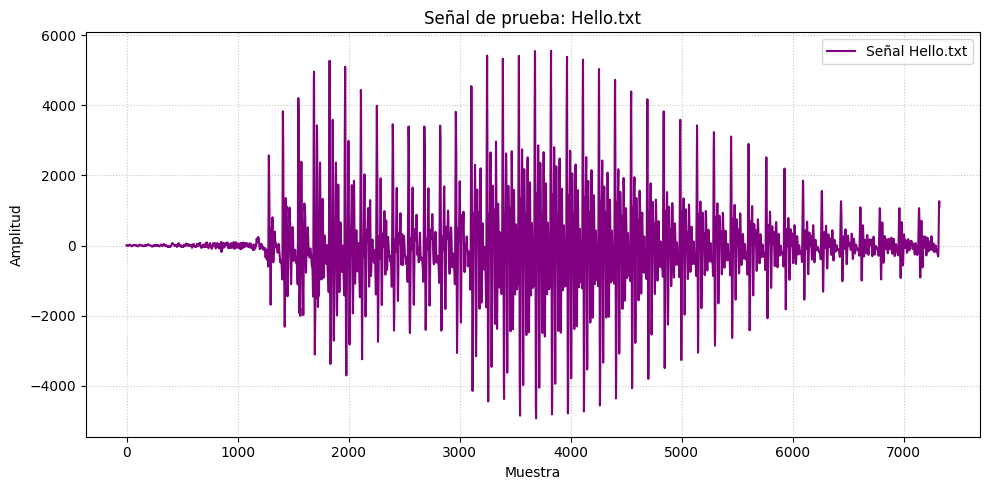

In [9]:
salida_hello = np.loadtxt('hello.txt')
plt.figure(figsize=(10, 5))
plt.plot(salida_hello, label='Señal Hello.txt', color='purple')
plt.xlabel('Muestra')
plt.ylabel('Amplitud')
plt.title('Señal de prueba: Hello.txt')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

fs = 16000 # Frecuencia de muestreo (16 kHz)
salida_hello = np.loadtxt('hello.txt')
N_muestras = len(salida_hello)

fonemas = [
    (0, 1270, 'hh', 'sordo'),
    (1270, 2379, 'eh', 'sonoro'),
    (2379, 3046, 'l', 'sonoro'),
    (3046, 5300, 'o', 'sonoro'),
    (5300, 7341, 'uw', 'sonoro')
]

orden = 14
senal_sintetizada = np.zeros(N_muestras)

for inicio, fin, nombre, tipo in fonemas:
    
    segmento_fonema = salida_hello[inicio:fin]
    N_seg = len(segmento_fonema)
    
    #multiplicamos por ventana de Hamming para suavizar bordes
    segmento_ventaneado = segmento_fonema * np.hamming(N_seg)

    #APLICAMOS LEVINSON
    r = autocorrelacion(segmento_ventaneado)
    centro = len(segmento_ventaneado) - 1
    r_cortada = r[centro : centro + orden + 1] / N_seg
    coefs, E, matriz_A = levinson_durbin(r_cortada, orden)

    # (Asumiendo que E es un vector con los errores para cada orden, tomamos el 14)
    G = np.sqrt(E[orden]) 
    print(f"Fonema: /{nombre}/ | Tipo: {tipo} | Ganancia G: {G:.4f}")
    
    # 5. Generación de la Excitación x[n]
    x = np.zeros(N_seg)
    
    if tipo == 'sordo':
        # Ruido blanco con varianza 1 (La amplitud se la da la ganancia G luego)
        rng = np.random.default_rng()
        x = rng.normal(0, 1, N_seg)
        
    elif tipo == 'sonoro':
        # Tren de impulsos a 120 Hz
        # ¿Cada cuántas muestras metemos un pulso? = Fs / F0
        periodo_muestras = int(fs / 120) # fs / F0 = 16000 / 120 ≈ 133 muestras
        x[::periodo_muestras] = 1.0 # Colocamos un '1' cada ~133 muestras
        
    # El denominador del filtro AR es [1, a1, a2, ..., ap]
    denominador = np.concatenate(([1], coefs))
    
    # Sintetizamos pasando la excitación por el tracto vocal
    y_segmento = lfilter([G], denominador, x)
    
    # 7. Guardamos el tramo en la señal final
    senal_sintetizada[inicio:fin] = y_segmento

Fonema: /hh/ | Tipo: sordo | Ganancia G: 8.4204
Fonema: /eh/ | Tipo: sonoro | Ganancia G: 63.5283
Fonema: /l/ | Tipo: sonoro | Ganancia G: 36.1530
Fonema: /o/ | Tipo: sonoro | Ganancia G: 62.2495
Fonema: /uw/ | Tipo: sonoro | Ganancia G: 14.8341


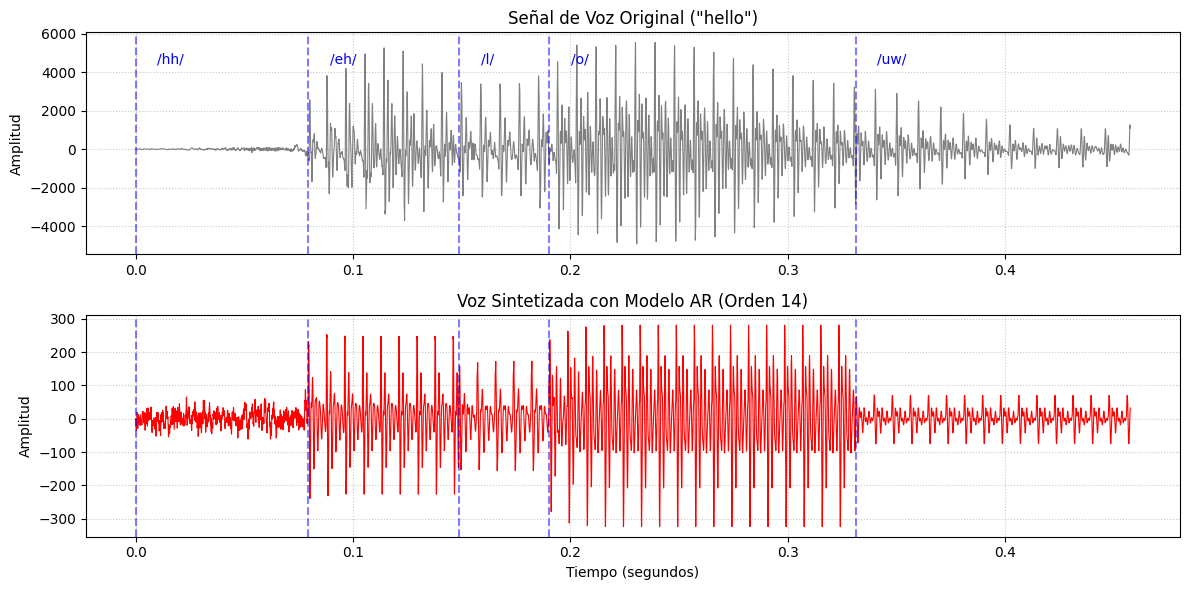

In [11]:
tiempo = np.arange(N_muestras) / fs

plt.figure(figsize=(12, 6))

# Graficamos la señal original arriba
plt.subplot(2, 1, 1)
plt.plot(tiempo, salida_hello, color='gray', linewidth=0.8)
plt.title('Señal de Voz Original ("hello")')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':', alpha=0.7)

# Graficamos la señal sintetizada abajo
plt.subplot(2, 1, 2)
plt.plot(tiempo, senal_sintetizada, color='red', linewidth=0.8)
plt.title('Voz Sintetizada con Modelo AR (Orden 14)')
plt.xlabel('Tiempo (segundos)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle=':', alpha=0.7)

# Líneas verticales
for inicio, _, nombre, _ in fonemas:
    t_inicio = inicio / fs
    plt.subplot(2, 1, 1)
    plt.axvline(x=t_inicio, color='blue', linestyle='--', alpha=0.5)
    plt.text(t_inicio + 0.01, np.max(salida_hello)*0.8, f'/{nombre}/', color='blue')
    
    plt.subplot(2, 1, 2)
    plt.axvline(x=t_inicio, color='blue', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [12]:
import scipy.io.wavfile as wavfile

# Función auxiliar para normalizar el audio al estándar de 16 bits
def guardar_audio(nombre_archivo, senal, frec_muestreo):
    # 1. Normalizamos la señal para que su pico máximo sea 1
    senal_norm = senal / np.max(np.abs(senal))
    # 2. La multiplicamos por el valor máximo de 16-bits y la convertimos
    senal_int16 = np.int16(senal_norm * 32767)
    # 3. Guardamos el archivo
    wavfile.write(nombre_archivo, frec_muestreo, senal_int16)
    print(f"¡Audio guardado: {nombre_archivo}!")

# Guardamos ambas señales
guardar_audio('hello_original.wav', salida_hello, fs)
guardar_audio('hello_sintetizado.wav', senal_sintetizada, fs)

¡Audio guardado: hello_original.wav!
¡Audio guardado: hello_sintetizado.wav!


In [13]:
from IPython.display import Audio, display

print("Escuchando: Señal Original")
display(Audio(salida_hello, rate=fs))

print("Escuchando: Señal Sintetizada")
display(Audio(senal_sintetizada, rate=fs))

Escuchando: Señal Original


Escuchando: Señal Sintetizada
